# 02 以 LSTM 預測預期報酬（μ）

均值—變異數模型需要每檔股票的**預期報酬**。本研究以一個跨股票共用（pooled）的單層 LSTM，用過去 63 個交易日的價量特徵預測未來 63 個交易日（約一季）的報酬。

**模型**：`Input(63×19) → LSTM(32) → Dropout(0.35) → Dense(16) → LeakyReLU(0.1) → Dense(1)`，MSE loss、Adam、early stopping（patience 10）。

**特徵（19 個）**：開高低收、成交量／金額／筆數、日報酬、MA20/60、乖離率、ROC20/60、60 日年化波動、量比、60 日價格區間位置。

**防止資訊洩漏**：

1. 只用「標籤在決策日當天或之前已實現」的樣本訓練（即樣本日期 $t$ 滿足 $t + 63 \le$ 決策日）。
2. 每檔股票依時間切成 85% 訓練、15% 驗證，兩段之間留 63 天 purge，避免標籤重疊造成洩漏。
3. 標準化器只在訓練段 fit。
4. 每一季都以截至當季決策日的資料**重新訓練**。

實作：[`src/qaportfolio/forecast_lstm.py`](../src/qaportfolio/forecast_lstm.py)。

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from qaportfolio.config import load_config
from qaportfolio.pipeline import schedule_from_cfg, load_prices
from qaportfolio import analysis, plotting
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 30)
cfg = load_config()
schedule = schedule_from_cfg(cfg)
SUMMARY = cfg["paths"]["results"] / "summary"

## 1. 各季樣本外預測品質

In [2]:
fc = pd.read_csv(SUMMARY / "forecast.csv", index_col=0)
fc[["n_train_sequences", "best_epoch", "MAE", "RMSE", "R2", "RankIC", "DirAcc", "RankIC_decision_vs_holding"]]

,n_train_sequences,best_epoch,MAE,RMSE,R2,RankIC,DirAcc,RankIC_decision_vs_holding
2025_03,242181,1,0.1135,0.1473,-0.6732,0.0067,0.4013,-0.0935
2025_06,245596,5,0.1456,0.2276,-0.1404,0.1314,0.6419,0.1811
2025_09,246281,2,0.1577,0.2429,-0.1125,0.0695,0.6231,0.1205
2025_12,249474,1,0.1674,0.2694,-0.0366,0.1742,0.6594,0.1613
2026_03,243682,18,0.2673,0.4180,-0.2601,0.0786,0.7029,-0.2696


**指標說明**：`RankIC` 為決策日前 63 個交易日（這些樣本的標籤皆在決策日後才實現）每日橫斷面 Spearman 相關的平均；
`RankIC_decision_vs_holding` 為決策日當天的預測與**實際持有期報酬**的橫斷面 Spearman 相關，也就是投資組合實際用到的那一組 μ 的排序能力。

## 2. 預測 vs. 實現

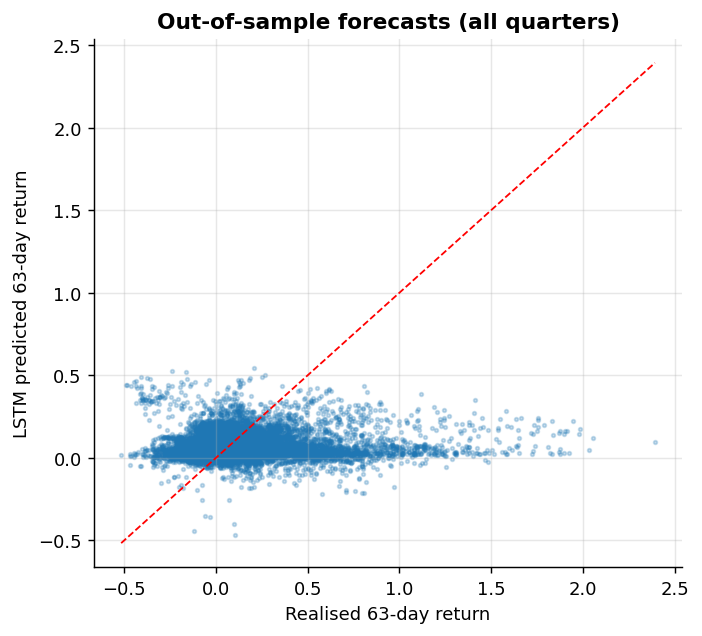

In [3]:
from IPython.display import Image
Image(filename=str(cfg["paths"]["results"] / "figures" / "forecast_scatter.png"))

## 3. 訓練過程

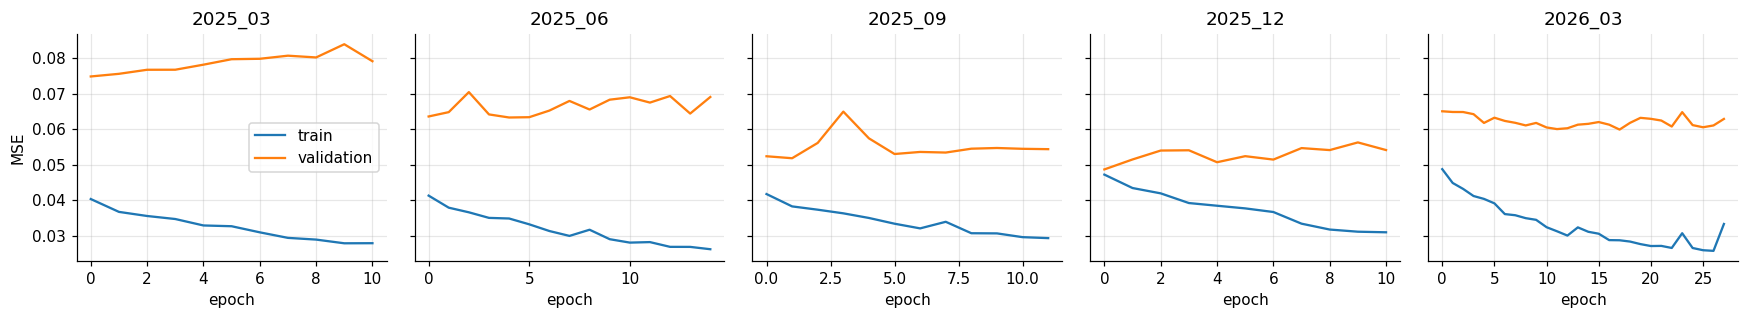

In [4]:
fig, axes = plt.subplots(1, len(schedule), figsize=(16, 3), sharey=True)
for ax, w in zip(axes, schedule):
    h = pd.read_csv(cfg["paths"]["results"] / w.quarter / "training_history.csv")
    ax.plot(h["loss"], label="train"); ax.plot(h["val_loss"], label="validation")
    ax.set_title(w.quarter); ax.set_xlabel("epoch")
axes[0].set_ylabel("MSE"); axes[0].legend()
plt.tight_layout()

## 4. 決策日的預期報酬（μ）

In [5]:
mu = pd.DataFrame({w.quarter: pd.read_csv(cfg["paths"]["results"] / w.quarter / "mu.csv", dtype={"stock_id": str}).set_index("stock_id")["mu"] for w in schedule})
mu.describe().T

,count,mean,std,min,25%,50%,75%,max
2025_03,50.0000,0.0408,0.0392,-0.0175,0.0132,0.0395,0.0549,0.1795
2025_06,50.0000,0.0734,0.0609,-0.0421,0.0287,0.0620,0.1125,0.2374
2025_09,51.0000,0.0496,0.0505,-0.1600,0.0292,0.0550,0.0711,0.1821
2025_12,50.0000,0.1122,0.0890,-0.0544,0.0437,0.1113,0.1516,0.4372
2026_03,49.0000,0.0714,0.0889,-0.0164,0.0276,0.0346,0.0623,0.4138
